---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: QLoRA com GPT-2 para Análise de Sentimentos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/HuggingFace-FFD21E?style=for-the-badge&logo=huggingface&logoColor=black"/>
</div>

---

> ℹ️ **Requisito de Hardware**
>
> Este notebook realiza fine-tuning do **GPT-2** (~124M parâmetros) com QLoRA em avaliações de filmes. Pode ser executado **localmente em CPU ou MPS** (Apple Silicon) — sem quantização, mas com tempo maior.
>
> | Hardware | Quantização | Tempo estimado |
> |---|---|---|
> | CPU (local) | FP32 — sem BitsAndBytes | ~15–30 minutos |
> | MPS (Apple Silicon) | FP32 — sem BitsAndBytes | ~10–15 minutos |
> | T4 GPU (Colab) | NF4 4-bit (QLoRA completo) | ~3–6 minutos |
>
> Para GPU no Google Colab: `Menu → Runtime → Change runtime type → T4 GPU`

In [ ]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
# %pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt

# bitsandbytes NÃO está no requirements.txt — é necessário para quantização NF4 4-bit (QLoRA completo)
# em CPU/MPS, o bitsandbytes não tem suporte nativo; o notebook detecta isso automaticamente
# instale apenas se estiver executando em GPU (Colab/servidor CUDA):
# %pip install -q bitsandbytes

---

<div align="center">

## <span style="color:#1E90FF;">Por que PEFT? O Custo do Fine-Tuning Completo</span>

</div>

O **fine-tuning completo** (*full fine-tuning*) consiste em atualizar **todos os parâmetros** de um modelo pré-treinado durante o treinamento em um novo domínio ou tarefa. Esse processo exige memória para três componentes simultâneos:

1. **Pesos do modelo** — os parâmetros em si;
2. **Gradientes** — derivadas parciais de cada peso, necessárias para a retropropagação;
3. **Estados do otimizador** — o Adam armazena duas matrizes de momentum (*m* e *v*) por parâmetro.

O custo total em FP32 para um parâmetro é portanto **4× o tamanho dos pesos** (1× pesos + 1× gradientes + 2× Adam states):

| Modelo | Parâmetros | Pesos (FP32) | + Gradientes | + Adam States | **Total** |
|---|---|---|---|---|---|
| GPT-2 | 124 M | ~0,5 GB | ~0,5 GB | ~1,0 GB | **~2 GB** |
| Llama-2-7B | 7 B | ~28 GB | ~28 GB | ~56 GB | **~112 GB** |
| Llama-3-70B | 70 B | ~280 GB | ~280 GB | ~560 GB | **~1,1 TB** |

Treinar modelos como Llama-3-70B requer clusters de GPUs de alto custo — inviável para a maioria dos pesquisadores e empresas.

**PEFT** (*Parameter-Efficient Fine-Tuning*) resolve esse problema: **congela os pesos pré-treinados** e adiciona um pequeno número de parâmetros extras treináveis. Os gradientes e estados do otimizador são calculados apenas sobre esses parâmetros menores, reduzindo dramaticamente o custo de memória e tempo de treinamento.

---

<div align="center">

## <span style="color:#1E90FF;">LoRA: Low-Rank Adaptation</span>

</div>

O **LoRA** (*Low-Rank Adaptation*, Hu et al., 2021) é a técnica PEFT mais amplamente adotada. A ideia central é que as **atualizações de pesos** durante o fine-tuning têm *baixo rank intrínseco* — ou seja, podem ser aproximadas por um produto de duas matrizes muito menores.

### Formulação Matemática

No fine-tuning completo, cada matriz de peso $W \in \mathbb{R}^{d \times k}$ é atualizada por um incremento $\Delta W$:

$$W' = W + \Delta W$$

O $\Delta W$ tem $d \times k$ parâmetros — exatamente o mesmo tamanho de $W$.

O LoRA **fatoriza** esse incremento como produto de duas matrizes de rank baixo:

$$\Delta W = B \cdot A, \quad B \in \mathbb{R}^{d \times r}, \quad A \in \mathbb{R}^{r \times k}, \quad r \ll \min(d, k)$$

O número de parâmetros cai de $d \times k$ para $r \times (d + k)$. Para a camada `c_attn` do GPT-2 ($d=768$, $k=2304$, $r=8$):

$$\text{LoRA: } 8 \times (768 + 2304) = 24.576 \text{ params} \quad \text{vs} \quad \text{Full: } 768 \times 2304 = 1.769.472 \text{ params}$$

Uma **redução de 72×** nessa camada.

### Forward Pass com LoRA

Durante o forward pass, a saída é calculada como:

$$h = W x + \frac{\alpha}{r} \cdot B A x$$

onde $\alpha/r$ é o fator de escala que controla a intensidade da adaptação.

**Inicialização:** $A$ é inicializada com distribuição Gaussiana; $B$ é inicializada com zeros — garantindo que $\Delta W = 0$ no início do treinamento (sem perturbação ao modelo pré-treinado).

### Parâmetros LoRA

| Parâmetro | Descrição | Valor neste notebook |
|---|---|---|
| `r` (rank) | Dimensão das matrizes A e B — controla a capacidade expressiva do adaptador | 8 |
| `lora_alpha` | Fator de escala; a taxa efetiva de adaptação é $\alpha / r$ | 16 (escala = 2.0) |
| `target_modules` | Camadas que recebem adaptadores LoRA — específicas de cada arquitetura | `["c_attn", "c_proj"]` |
| `lora_dropout` | Dropout aplicado nas camadas LoRA para regularização | 0.05 |
| `bias` | Se os vetores de bias também são adaptados | `"none"` (apenas pesos) |

---

<div align="center">

## <span style="color:#1E90FF;">Quantização: FP32 → NF4</span>

</div>

**Quantização** é o processo de representar os pesos de um modelo com menor precisão numérica, reduzindo o uso de memória sem retreinar o modelo. A próxima célula de código visualiza esse processo.

### Escada de Precisão

| Formato | Bits | Bytes/param | Memória (GPT-2 124M) | Tipo |
|---|---|---|---|---|
| FP32 | 32 | 4,0 | ~496 MB | Ponto flutuante padrão |
| FP16 / BF16 | 16 | 2,0 | ~248 MB | Ponto flutuante meia precisão |
| INT8 | 8 | 1,0 | ~124 MB | Inteiro com quantização uniforme |
| **NF4** | **4** | **0,5** | **~62 MB** | NormalFloat 4-bit (não-uniforme) |

### NF4 vs INT4: Por que NF4 é Melhor?

A quantização **INT4** usa bins de tamanho uniforme distribuídos linearmente no intervalo dos valores. O problema é que os pesos de modelos pré-treinados seguem uma **distribuição normal** centrada em zero — a maioria dos valores está próxima de 0, e poucos valores são grandes.

O **NF4** (*NormalFloat 4-bit*, Dettmers et al., 2023) usa **bins não-uniformes** calibrados para a distribuição normal: mais bins próximos de zero (onde os valores são mais frequentes) e menos bins nas caudas. Isso significa que NF4 usa os 16 níveis de representação de forma muito mais eficiente do que INT4 para os pesos típicos de LLMs.

### Double Quantization

O QLoRA também aplica **double quantization**: as constantes de quantização (que mapeiam o intervalo dos pesos para o intervalo NF4) são elas mesmas quantizadas com NF4, economizando ~0,5 GB adicionais por bilhão de parâmetros.

### QLoRA = LoRA + Quantização NF4

A combinação é direta:
1. O **modelo base** é carregado congelado em **NF4 4-bit** (mínimo de memória);
2. **Adaptadores LoRA** em FP16 são adicionados às camadas de atenção;
3. Apenas os adaptadores LoRA recebem gradientes — custo de otimizador mínimo;
4. No forward pass, os pesos NF4 são **desquantizados para BF16/FP16** momentaneamente para o cálculo matricial.

---

<div align="center">

## <span style="color:#1E90FF;">GPT-2: Arquitetura e Módulos LoRA</span>

</div>

O **GPT-2** (Radford et al., 2019) é um *decoder-only Transformer* pré-treinado para modelagem de linguagem causal — prevê o próximo token dado o contexto anterior. É um modelo ideal para introduzir QLoRA: pequeno o suficiente para rodar localmente, mas complexo o suficiente para demonstrar os benefícios do fine-tuning.

| Característica | GPT-2 (small) |
|---|---|
| Parâmetros | ~124 M |
| Camadas Transformer | 12 |
| Dimensão oculta (*d_model*) | 768 |
| Cabeças de atenção | 12 |
| Vocabulário | 50.257 tokens (BPE) |
| Contexto máximo | 1.024 tokens |

### Pipeline do GPT-2

```
Token IDs  →  Embedding (50.257 → 768)  +  Positional Encoding
                            ↓
         12 × Bloco Transformer:
             ├── LayerNorm
             ├── Multi-Head Attention
             │       ├── c_attn (768 → 2304)  ← LoRA aplicado (Q, K, V fusionados)
             │       └── c_proj (768 → 768)   ← LoRA aplicado (projeção de saída)
             ├── LayerNorm
             └── MLP
                     ├── c_fc   (768 → 3072)
                     └── c_proj (3072 → 768)  ← LoRA aplicado (mesmo nome)
                            ↓
         Language Model Head (768 → 50.257)
```

### Por que `c_attn` e `c_proj`?

| Módulo | Shape | Papel | LoRA |
|---|---|---|---|
| `c_attn` | 768 × 2304 | Projeções Q, K, V **fusionadas** em uma única matriz | ✓ Sim |
| `c_proj` | 768 × 768 | Projeção de saída da atenção + segunda camada do MLP | ✓ Sim |
| `c_fc` | 768 × 3072 | Expansão do MLP (feed-forward) | ✗ Não |

> **Nota:** No GPT-2, diferente de modelos como Llama, as projeções Q, K e V são **computadas juntas** em `c_attn` (razão pela qual sua dimensão de saída é 2304 = 768 × 3). Ao aplicar LoRA em `c_attn`, adaptamos as três projeções simultaneamente. O padrão `"c_proj"` corresponde tanto ao `attn.c_proj` quanto ao `mlp.c_proj` de cada bloco.

In [1]:
# imports
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model

warnings.filterwarnings('ignore')

# fixando seed para reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# detecção de dispositivo
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f'GPU disponível : {torch.cuda.get_device_name(0)}')
    print(f'Memória total  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('Apple Silicon (MPS) disponível.')
else:
    DEVICE = 'cpu'
    print('GPU não encontrada — usando CPU.')

# bitsandbytes (quantização NF4) só funciona com CUDA
USE_QUANTIZATION = torch.cuda.is_available()

if USE_QUANTIZATION:
    from transformers import BitsAndBytesConfig
    from peft import prepare_model_for_kbit_training
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',            # NormalFloat 4-bit
        bnb_4bit_compute_dtype=torch.float16, # desquantiza para FP16 no forward
        bnb_4bit_use_double_quant=True,       # quantiza também as constantes de quantização
    )
    print('\nQuantização NF4 (QLoRA completo) configurada.')
else:
    bnb_config = None
    print(f'\nQuantização desativada ({DEVICE.upper()}) — modelo carregado em FP32.')

print(f'PyTorch : {torch.__version__}')

/Users/mitoura/Desktop/FIAP/Materiais/03_GenerativeAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Apple Silicon (MPS) disponível.

Quantização desativada (MPS) — modelo carregado em FP32.
PyTorch : 2.10.0


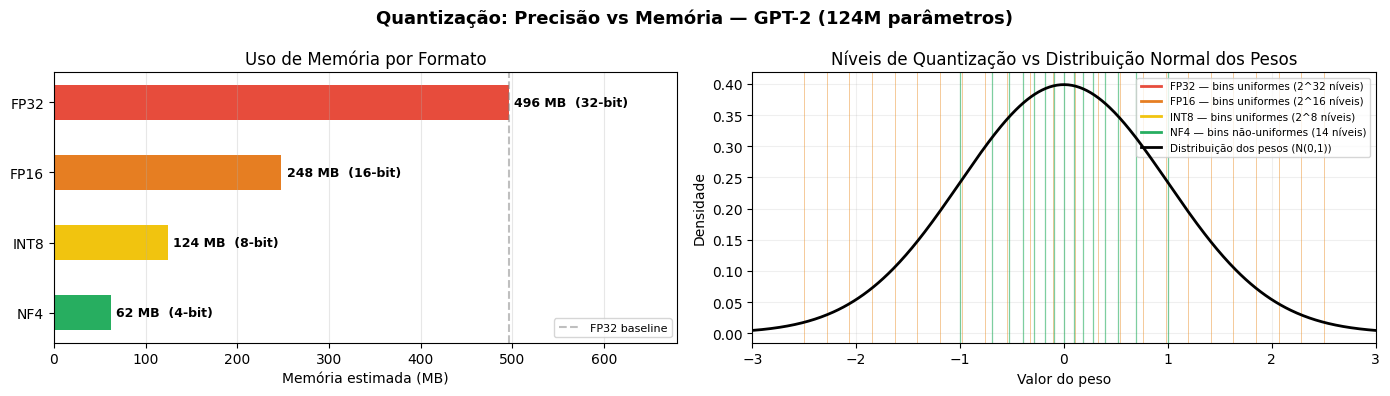

Redução de memória em relação ao FP32:
  FP32  (32-bit) :  496 MB  →  1.0× menor que FP32
  FP16  (16-bit) :  248 MB  →  2.0× menor que FP32
  INT8  ( 8-bit) :  124 MB  →  4.0× menor que FP32
  NF4   ( 4-bit) :   62 MB  →  8.0× menor que FP32


In [2]:
# visualização das precisões numéricas: uso de memória e distribuição dos níveis
PRECISOES  = ['FP32', 'FP16', 'INT8', 'NF4']
BITS       = [32, 16, 8, 4]
MEMORIA_MB = [496, 248, 124, 62]   # estimativa para GPT-2 124M params
CORES      = ['#E74C3C', '#E67E22', '#F1C40F', '#27AE60']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Quantização: Precisão vs Memória — GPT-2 (124M parâmetros)', fontsize=13, fontweight='bold')

# painel esquerdo: memória por formato (barras horizontais)
barras = axes[0].barh(PRECISOES, MEMORIA_MB, color=CORES, height=0.5)
axes[0].set_xlabel('Memória estimada (MB)')
axes[0].set_title('Uso de Memória por Formato')
axes[0].invert_yaxis()
for b, m, bits in zip(barras, MEMORIA_MB, BITS):
    axes[0].text(m + 6, b.get_y() + b.get_height() / 2,
                 f'{m} MB  ({bits}-bit)', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlim(0, 680)
axes[0].axvline(496, color='gray', linestyle='--', alpha=0.5, label='FP32 baseline')
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

# painel direito: bins de quantização sobre a distribuição normal dos pesos
x = np.linspace(-3, 3, 500)
normal_pdf = np.exp(-0.5 * x ** 2) / np.sqrt(2 * np.pi)  # N(0, 1)

# bins NF4: não-uniformes, otimizados para a distribuição normal (Dettmers et al., 2023)
nf4_bins = np.array([-1.0, -0.6962, -0.5251, -0.3949, -0.2844,
                     -0.1848, -0.0932,  0.0,    0.0932,  0.1848,
                      0.2844,  0.3949,  0.5251,  0.6962,  1.0])

for prec, cor, bits in zip(PRECISOES, CORES, BITS):
    if prec == 'NF4':
        for b in nf4_bins:
            axes[1].axvline(b, color=cor, alpha=0.6, linewidth=0.9)
        axes[1].plot([], [], color=cor, linewidth=2,
                     label=f'NF4 — bins não-uniformes ({len(nf4_bins)-1} níveis)')
    else:
        n_bins = min(2 ** bits, 24)  # limita a visualização a 24 linhas
        grid = np.linspace(-2.5, 2.5, n_bins)
        for g in grid:
            axes[1].axvline(g, color=cor, alpha=0.25, linewidth=0.5)
        axes[1].plot([], [], color=cor, linewidth=2,
                     label=f'{prec} — bins uniformes (2^{bits} níveis)')

axes[1].plot(x, normal_pdf, 'k-', linewidth=2, label='Distribuição dos pesos (N(0,1))', zorder=10)
axes[1].set_title('Níveis de Quantização vs Distribuição Normal dos Pesos')
axes[1].set_xlabel('Valor do peso')
axes[1].set_ylabel('Densidade')
axes[1].legend(fontsize=7.5, loc='upper right')
axes[1].grid(alpha=0.2)
axes[1].set_xlim(-3, 3)

plt.tight_layout()
plt.show()

print('Redução de memória em relação ao FP32:')
for p, m, b in zip(PRECISOES, MEMORIA_MB, BITS):
    print(f'  {p:5s} ({b:2d}-bit) : {m:4d} MB  →  {496/m:.1f}× menor que FP32')

Dataset carregado:
  Total de amostras : 17,057
  Colunas           : ['text', 'label']

Distribuição de classes:
label
Positive    9797
Negative    7260

Comprimento médio das avaliações : 423 caracteres
Comprimento mediano              : 248 caracteres
Comprimento máximo               : 11,497 caracteres


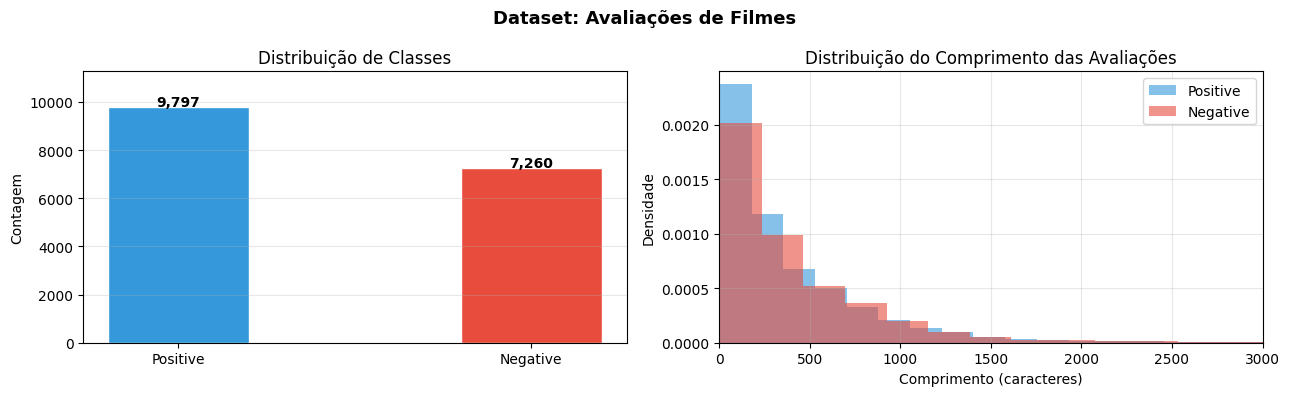


Amostras selecionadas para treino: 500

Exemplo de texto formatado:
Review: THIS HAS TO BE ONE OF THE MOST PATHETIC FILMS I HAVE EVER SEEN!!!!!!!!!! This was`nt scary apart from the part that only few people have seen because it was deleted, the so-called spider walk scene, and the "bit" with the crucifix . This was a disgusting and hilarious film, it did not scare 


In [3]:
# carregamento e preparação do dataset de avaliações de filmes
import seaborn as sns

df = pd.read_csv('dataset/dataset.csv')

print('Dataset carregado:')
print(f'  Total de amostras : {len(df):,}')
print(f'  Colunas           : {df.columns.tolist()}')
print(f'\nDistribuição de classes:')
print(df['label'].value_counts().to_string())
print(f'\nComprimento médio das avaliações : {df["text"].str.len().mean():.0f} caracteres')
print(f'Comprimento mediano              : {df["text"].str.len().median():.0f} caracteres')
print(f'Comprimento máximo               : {df["text"].str.len().max():,} caracteres')

# visualização da distribuição do dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Dataset: Avaliações de Filmes', fontsize=13, fontweight='bold')

# distribuição de classes
contagens = df['label'].value_counts()
cores_bar = ['#3498DB', '#E74C3C']
axes[0].bar(contagens.index, contagens.values, color=cores_bar, width=0.4, edgecolor='white')
axes[0].set_title('Distribuição de Classes')
axes[0].set_ylabel('Contagem')
for i, (lbl, cnt) in enumerate(contagens.items()):
    axes[0].text(i, cnt + 50, f'{cnt:,}', ha='center', fontweight='bold')
axes[0].set_ylim(0, contagens.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# distribuição do comprimento das avaliações
for lbl, cor in zip(['Positive', 'Negative'], cores_bar):
    comprimentos = df[df['label'] == lbl]['text'].str.len()
    axes[1].hist(comprimentos, bins=50, color=cor, alpha=0.6, label=lbl, density=True)
axes[1].set_title('Distribuição do Comprimento das Avaliações')
axes[1].set_xlabel('Comprimento (caracteres)')
axes[1].set_ylabel('Densidade')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 3000)

plt.tight_layout()
plt.show()

# --- preparação para fine-tuning causal LM ---
N_SAMPLES  = 500   # aumentar para ≥2000 em GPU para melhor aprendizado
MAX_LENGTH = 128   # tokens por sequência

df_treino = df.sample(n=N_SAMPLES, random_state=SEED).reset_index(drop=True)

def formatar_exemplo(row: pd.Series) -> str:
    """Formata cada avaliação no template causal LM para fine-tuning."""
    return f"Review: {row['text']}\nSentiment: {row['label']}\n"

df_treino['texto_formatado'] = df_treino.apply(formatar_exemplo, axis=1)

print(f'\nAmostras selecionadas para treino: {len(df_treino)}')
print(f'\nExemplo de texto formatado:')
print(df_treino['texto_formatado'].iloc[0][:300])

---

<div align="center">

## <span style="color:#1E90FF;">Dataset e Tokenização</span>

</div>

### Por que Formatação Causal LM?

O GPT-2 é um modelo de **linguagem causal** — prevê o próximo token dado o contexto. Para ensiná-lo a identificar sentimentos, formatamos cada amostra como um texto completo que o modelo aprende a *continuar*:

```
Review: The movie was absolutely incredible...\nSentiment: Positive\n
```

O modelo aprende que, dado o contexto `Review: [...] \nSentiment:`, a continuação natural é `Positive` ou `Negative`. Isso é diferente da abordagem de classificação:

| Abordagem | Tipo de saída | Função de loss | Exemplo |
|---|---|---|---|
| Classificação (DistilBERT) | Logit binário | Cross-entropy sobre 2 classes | → `{0, 1}` |
| Causal LM (GPT-2 + QLoRA) | Próximo token | Cross-entropy sobre vocabulário (50.257) | → `"Positive"` |

### DataCollatorForLanguageModeling

O `DataCollatorForLanguageModeling(mlm=False)` copia `input_ids` para `labels`, fazendo com que a loss seja calculada sobre **todos os tokens da sequência** — incluindo o prefixo `Review:`. Esse é o comportamento padrão para modelos causais e ensina o modelo o formato completo da tarefa.

O parâmetro `mlm=False` distingue o modo causal (GPT-style) do modo *masked language modeling* (`mlm=True`, BERT-style).

In [4]:
MODEL_NAME = 'gpt2'

# carrega o tokenizador BPE do GPT-2
# GPT-2 não tem pad_token por padrão — definimos como eos_token para permitir batching
tokenizador = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizador.pad_token    = tokenizador.eos_token
tokenizador.padding_side = 'right'

def tokenizar(exemplo: dict) -> dict:
    """Tokeniza o texto formatado com truncamento e padding até MAX_LENGTH."""
    return tokenizador(
        exemplo['texto'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )

# converte o DataFrame para Dataset HuggingFace
hf_dataset = Dataset.from_dict({'texto': df_treino['texto_formatado'].tolist()})
hf_dataset = hf_dataset.map(tokenizar, batched=True, remove_columns=['texto'])
hf_dataset.set_format('torch')

# divisão treino/validação (80/20) estratificada por seed
split    = hf_dataset.train_test_split(test_size=0.2, seed=SEED)
train_ds = split['train']
val_ds   = split['test']

print('Tokenização concluída.')
print(f'  Vocabulário  : {tokenizador.vocab_size:,} tokens')
print(f'  Treino       : {len(train_ds)} amostras')
print(f'  Validação    : {len(val_ds)} amostras')
print(f'  Shape        : {train_ds[0]["input_ids"].shape}')
print(f'\nExemplo — primeiros 15 token ids : {train_ds[0]["input_ids"][:15].tolist()}')
print(f'Decodificado                     : {tokenizador.decode(train_ds[0]["input_ids"][:15])!r}')

Map: 100%|██████████| 500/500 [00:00<00:00, 11483.19 examples/s]

Tokenização concluída.
  Vocabulário  : 50,257 tokens
  Treino       : 400 amostras
  Validação    : 100 amostras
  Shape        : torch.Size([128])

Exemplo — primeiros 15 token ids : [14832, 25, 1867, 561, 345, 466, 611, 345, 714, 307, 257, 17343, 30, 1867, 611]
Decodificado                     : 'Review: What would you do if you could be a superhero? What if'


---

<div align="center">

## <span style="color:#1E90FF;">Configurando QLoRA: Modelo + Adaptadores LoRA</span>

</div>

A configuração do QLoRA ocorre em **duas etapas encadeadas**:

**1. Carregamento do modelo base** com quantização condicional:
- Em **CUDA**: `BitsAndBytesConfig` carrega os pesos em NF4 4-bit e os mantém congelados;
- Em **CPU/MPS**: o modelo é carregado em FP32 sem quantização (mesma lógica LoRA, sem NF4).

**2. Injeção dos adaptadores LoRA** via `get_peft_model`:
- `LoraConfig` especifica onde e como injetar os adaptadores;
- `get_peft_model` congela os pesos originais e adiciona as matrizes A e B LoRA.

### Parâmetros LoRA Escolhidos

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `r` | 8 | Rank moderado — equilibra expressividade e eficiência |
| `lora_alpha` | 16 | Escala = 16/8 = 2,0 — ligeiramente acima de 1 para acelerar aprendizado |
| `target_modules` | `["c_attn", "c_proj"]` | Cobre atenção QKV + output + MLP output do GPT-2 |
| `lora_dropout` | 0,05 | Baixo dropout — dataset pequeno, risco de overfitting controlado |
| `task_type` | `CAUSAL_LM` | Informa ao PEFT que a tarefa é geração causal |

### Conta de Parâmetros LoRA

Para `c_attn` (768 × 2304) com r=8:
$$\text{A: } 8 \times 2304 + \text{B: } 768 \times 8 = 18.432 + 6.144 = 24.576 \text{ params}$$
$$\text{vs. full: } 768 \times 2304 = 1.769.472 \text{ params} \quad (72\times \text{ redução})$$

In [5]:
# carregamento do GPT-2 com quantização condicional
kwargs_modelo: dict = {}

if USE_QUANTIZATION:
    kwargs_modelo['quantization_config'] = bnb_config
    kwargs_modelo['device_map']          = 'auto'  # distribui automaticamente em CUDA

modelo_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **kwargs_modelo)

if not USE_QUANTIZATION:
    modelo_base = modelo_base.to(DEVICE)

if USE_QUANTIZATION:
    # prepara o modelo para treinamento em k-bit (habilita gradient checkpointing)
    modelo_base = prepare_model_for_kbit_training(modelo_base)

total_params = sum(p.numel() for p in modelo_base.parameters())
print(f'Modelo carregado : {MODEL_NAME}')
print(f'Parâmetros totais: {total_params / 1e6:.1f}M')
print(f'Modo             : {"QLoRA (NF4 4-bit)" if USE_QUANTIZATION else f"FP32 ({DEVICE.upper()})"}')

# configura os adaptadores LoRA
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=['c_attn', 'c_proj'],   # atenção (QKV + output) e MLP output do GPT-2
)

# aplica LoRA — congela pesos base e adiciona matrizes A e B treináveis
modelo_lora = get_peft_model(modelo_base, peft_config)
modelo_lora.print_trainable_parameters()

Modelo carregado : gpt2
Parâmetros totais: 124.4M
Modo             : FP32 (MPS)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475


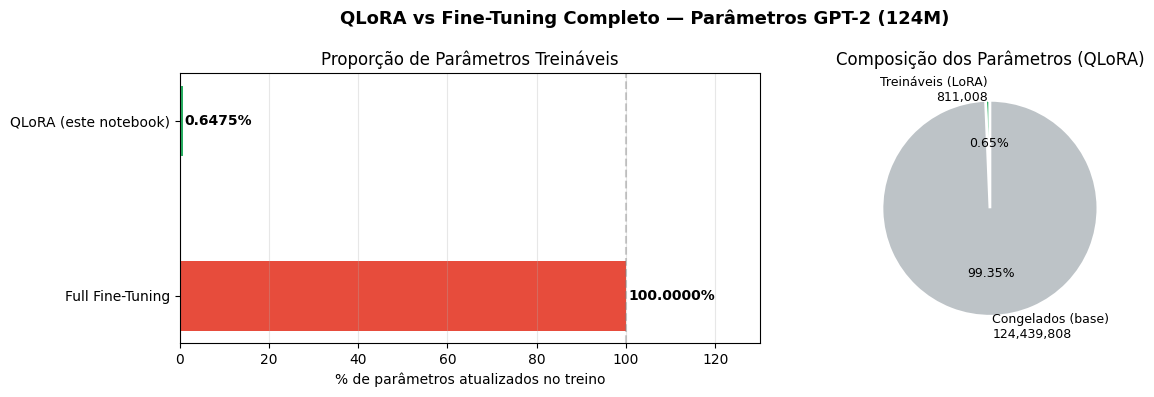

Total de parâmetros  : 125,250,816  (100.00%)
Treináveis (LoRA)    :    811,008  (0.6475%)
Congelados (base)    : 124,439,808  (99.35%)


In [6]:
# visualização dos parâmetros treináveis vs congelados
total_p, treina_p = 0, 0
for p in modelo_lora.parameters():
    total_p += p.numel()
    if p.requires_grad:
        treina_p += p.numel()
congela_p = total_p - treina_p

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('QLoRA vs Fine-Tuning Completo — Parâmetros GPT-2 (124M)', fontsize=13, fontweight='bold')

# painel esquerdo: % de parâmetros atualizados
rotulos   = ['Full Fine-Tuning', 'QLoRA (este notebook)']
pct_train = [100.0, treina_p / total_p * 100]
cores_bar = ['#E74C3C', '#27AE60']

barras = axes[0].barh(rotulos, pct_train, color=cores_bar, height=0.4)
for b, v in zip(barras, pct_train):
    axes[0].text(v + 0.5, b.get_y() + b.get_height() / 2,
                 f'{v:.4f}%', va='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('% de parâmetros atualizados no treino')
axes[0].set_title('Proporção de Parâmetros Treináveis')
axes[0].set_xlim(0, 130)
axes[0].axvline(100, color='gray', linestyle='--', alpha=0.4)
axes[0].grid(axis='x', alpha=0.3)

# painel direito: gráfico de pizza
axes[1].pie(
    [treina_p, congela_p],
    labels=[f'Treináveis (LoRA)\n{treina_p:,}', f'Congelados (base)\n{congela_p:,}'],
    colors=['#27AE60', '#BDC3C7'],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9},
)
axes[1].set_title('Composição dos Parâmetros (QLoRA)')

plt.tight_layout()
plt.show()

print(f'Total de parâmetros  : {total_p:>10,}  (100.00%)')
print(f'Treináveis (LoRA)    : {treina_p:>10,}  ({treina_p / total_p * 100:.4f}%)')
print(f'Congelados (base)    : {congela_p:>10,}  ({congela_p / total_p * 100:.2f}%)')

---

<div align="center">

## <span style="color:#1E90FF;">Fine-Tuning com QLoRA</span>

</div>

O treinamento usa o `Trainer` padrão do HuggingFace com o `DataCollatorForLanguageModeling`. **Não** usamos o `SFTTrainer` (da biblioteca `trl`) para manter o notebook alinhado com as dependências do projeto.

### Configuração de Treinamento

| Hiperparâmetro | Valor | Motivação |
|---|---|---|
| `num_train_epochs` | 3 | Dataset pequeno — mais épocas podem causar overfitting |
| `learning_rate` | 2e-4 | Alta para LoRA — apenas adaptadores são atualizados |
| `per_device_train_batch_size` | 8 | Cabe em CPU, MPS e T4 GPU; reduzir para 4 se houver OOM |
| `weight_decay` | 0,01 | Regularização L2 leve nos pesos dos adaptadores |
| `fp16` | Apenas CUDA | Precisão mista ativa somente com CUDA |
| `save_strategy` | `"no"` | Evita conflitos com o sistema de checkpoints do PEFT |

### DataCollator para Causal LM

```python
DataCollatorForLanguageModeling(tokenizer=tokenizador, mlm=False)
```

Com `mlm=False`, o collator copia `input_ids` para `labels`. A loss de entropia cruzada é computada sobre **todos os tokens** da sequência — tanto o prefixo `Review:` quanto o sufixo `Sentiment: Positive`. Isso é o comportamento correto para modelos causais: o modelo aprende a prever cada token dado seu contexto à esquerda.

> | Hardware | Tempo estimado |
> |---|---|
> | CPU | ~15–30 minutos |
> | MPS (Apple Silicon) | ~10–15 minutos |
> | T4 GPU (Colab) | ~3–6 minutos |

In [11]:
from accelerate.state import AcceleratorState
AcceleratorState._reset_state()   # evita erro se a célula for reexecutada

# coletor de dados para modelagem de linguagem causal
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizador,
    mlm=False,  # False = GPT-style causal LM; True = BERT-style masked LM
)

training_args = TrainingArguments(
    output_dir='./gpt2_qlora_sentimentos',
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy='epoch',
    logging_strategy='epoch',
    save_strategy='no',
    report_to='none',
    fp16=USE_QUANTIZATION,   # precisão mista apenas em CUDA
    seed=SEED,
)

trainer = Trainer(
    model=modelo_lora,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
)

passos_por_epoca = len(train_ds) // training_args.per_device_train_batch_size
print('Trainer configurado.')
print(f'  Amostras de treino : {len(train_ds)}')
print(f'  Passos por época   : {passos_por_epoca}')
print(f'  Total de passos    : {passos_por_epoca * int(training_args.num_train_epochs)}')

Trainer configurado.
  Amostras de treino : 400
  Passos por época   : 25
  Total de passos    : 250


In [12]:
%%time
# fine-tuning — apenas os adaptadores LoRA são atualizados
# os pesos base do GPT-2 permanecem completamente congelados
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.516400,3.469393
2,3.489600,3.466508
3,3.474000,3.464095
4,3.473700,3.459714
5,3.447900,3.461419
6,3.436600,3.457300
7,3.430500,3.456166
8,3.420600,3.457440
9,3.421900,3.456869
10,3.412000,3.456886


CPU times: user 16.1 s, sys: 5.33 s, total: 21.5 s
Wall time: 1min 57s


TrainOutput(global_step=250, training_loss=3.4523161315917967, metrics={'train_runtime': 117.0402, 'train_samples_per_second': 34.176, 'train_steps_per_second': 2.136, 'total_flos': 263783448576000.0, 'train_loss': 3.4523161315917967, 'epoch': 10.0})

---

<div align="center">

## <span style="color:#1E90FF;">Resultados do Treinamento</span>

</div>

A métrica principal do fine-tuning de modelos causais é a **loss de entropia cruzada** sobre os tokens da sequência. Quanto menor a loss, melhor o modelo aprendeu a continuar os textos do dataset no formato desejado.

**O que observar nas curvas:**
- **Train loss** deve cair consistentemente a cada época;
- **Val loss** deve acompanhar a train loss — se a val loss começa a subir enquanto a train loss cai, há overfitting;
- Com apenas 400 amostras de treino e 3 épocas, overfitting severo é improvável.

A loss de um modelo de linguagem pode ser convertida em **perplexidade** ($PPL = e^{loss}$), uma métrica mais interpretável: uma PPL de 20 significa que o modelo está, em média, igualmente incerto entre 20 tokens possíveis a cada posição.

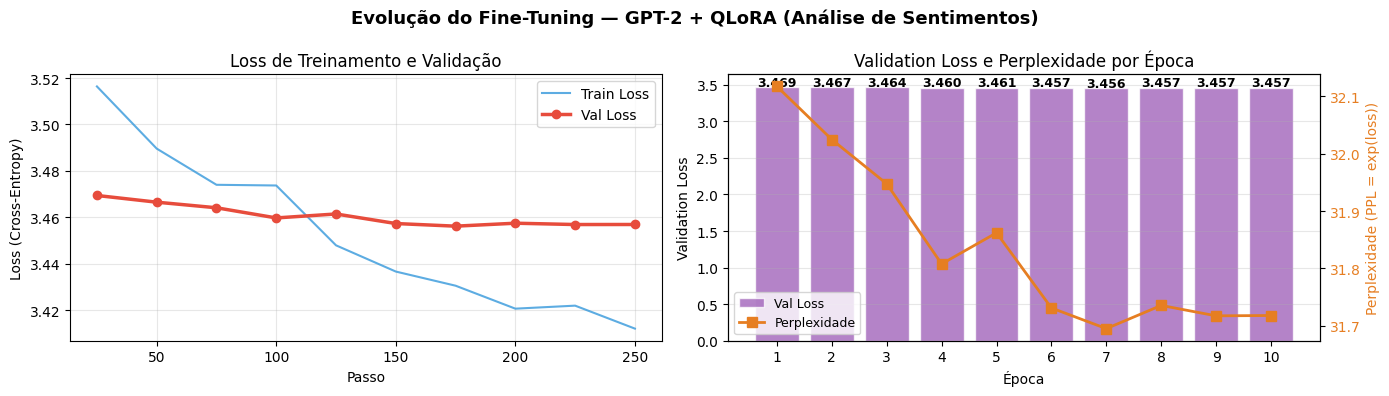

Melhor val loss  : 3.4562  (época 7)
Perplexidade PPL : 31.70


In [13]:
# extração e visualização das curvas de treinamento
log = trainer.state.log_history

train_steps = [x['step'] for x in log if 'loss'      in x and 'eval_loss' not in x]
train_loss  = [x['loss'] for x in log if 'loss'      in x and 'eval_loss' not in x]
eval_steps  = [x['step']      for x in log if 'eval_loss' in x]
eval_loss   = [x['eval_loss'] for x in log if 'eval_loss' in x]
eval_epocas = [x['epoch']     for x in log if 'eval_loss' in x]

# calcula perplexidade
train_ppl = [np.exp(l) for l in train_loss]
eval_ppl  = [np.exp(l) for l in eval_loss]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Evolução do Fine-Tuning — GPT-2 + QLoRA (Análise de Sentimentos)', fontsize=13, fontweight='bold')

# curvas de loss
axes[0].plot(train_steps, train_loss, color='#3498DB', linewidth=1.5, alpha=0.8, label='Train Loss')
axes[0].plot(eval_steps,  eval_loss,  color='#E74C3C', linewidth=2.5,
             marker='o', markersize=6, label='Val Loss')
axes[0].set_xlabel('Passo')
axes[0].set_ylabel('Loss (Cross-Entropy)')
axes[0].set_title('Loss de Treinamento e Validação')
axes[0].legend()
axes[0].grid(alpha=0.3)

# loss por época (barras + perplexidade)
eixo_x = list(range(1, len(eval_loss) + 1))
axes[1].bar(eixo_x, eval_loss, color='#9B59B6', alpha=0.75, edgecolor='white', label='Val Loss')
ax2 = axes[1].twinx()
ax2.plot(eixo_x, eval_ppl, color='#E67E22', linewidth=2, marker='s', markersize=7, label='Perplexidade')
ax2.set_ylabel('Perplexidade (PPL = exp(loss))', color='#E67E22')
ax2.tick_params(axis='y', labelcolor='#E67E22')

for ep, loss in zip(eixo_x, eval_loss):
    axes[1].text(ep, loss + 0.02, f'{loss:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss e Perplexidade por Época')
axes[1].set_xticks(eixo_x)
axes[1].grid(alpha=0.3, axis='y')

# legenda combinada
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

melhor_idx = int(np.argmin(eval_loss))
print(f'Melhor val loss  : {eval_loss[melhor_idx]:.4f}  (época {eval_epocas[melhor_idx]:.0f})')
print(f'Perplexidade PPL : {eval_ppl[melhor_idx]:.2f}')

---

<div align="center">

## <span style="color:#1E90FF;">Inferência: Modelo Base vs Fine-Tuned</span>

</div>

Para avaliar o efeito do fine-tuning, comparamos as respostas do **GPT-2 base** (sem treinamento) com as do **GPT-2 + QLoRA** (fine-tuned) para o mesmo prompt.

### Estratégia de Prompt

Fornecemos o prefixo e deixamos o modelo completar:

```
Review: [texto da avaliação]
Sentiment:                     ← modelo completa aqui
```

O GPT-2 base não foi treinado nesse formato — suas completações serão continuações genéricas do texto. O modelo fine-tuned aprendeu a produzir `Positive` ou `Negative` como continuação natural.

**Parâmetros de geração:**
- `temperature=0.1` — quase determinístico; concentra a probabilidade no token mais provável;
- `max_new_tokens=10` — precisamos apenas de `Positive` ou `Negative` + pontuação.

### Salvando o Adaptador LoRA

Uma vantagem crítica do PEFT: salvamos apenas os **pesos dos adaptadores** (~1–5 MB), não o modelo completo (~500 MB para GPT-2, ~14 GB para Llama-2-7B). Para redistribuir o modelo:

| Artefato | Tamanho | Conteúdo |
|---|---|---|
| Adaptador LoRA | ~1–5 MB | Matrizes A e B de cada camada adaptada |
| Modelo GPT-2 completo (FP32) | ~500 MB | Todos os 124M parâmetros |
| Modelo GPT-2 completo (NF4) | ~62 MB | Todos os parâmetros quantizados |

Para inferência em produção, carrega-se o modelo base uma vez e os diferentes adaptadores conforme necessário — cada adaptador é uma especialização barata.

In [14]:
import os

# avaliações de filmes externas para teste de inferência
avaliacoes_teste = [
    'The movie was absolutely incredible, a true masterpiece of modern cinema.',
    'Terrible film, complete waste of time. Avoid at all costs.',
    'Best film I have seen in years. Highly recommended to everyone.',
    'The plot was confusing and the acting was disappointing throughout.',
]

def gerar_sentimento(modelo, texto: str, max_new_tokens: int = 10) -> str:
    """Gera o sentimento previsto pelo modelo para uma avaliação de filme."""
    prompt  = f'Review: {texto}\nSentiment:'
    inputs  = tokenizador(prompt, return_tensors='pt', truncation=True, max_length=MAX_LENGTH)
    device_ = 'cuda' if USE_QUANTIZATION else DEVICE
    inputs  = {k: v.to(device_) for k, v in inputs.items()}

    modelo.eval()
    with torch.no_grad():
        output_ids = modelo.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizador.eos_token_id,
        )

    # decodifica apenas os tokens gerados (após o prompt)
    n_prompt = inputs['input_ids'].shape[1]
    novos_ids = output_ids[0][n_prompt:]
    return tokenizador.decode(novos_ids, skip_special_tokens=True).strip()

# carrega modelo base (sem fine-tuning) para comparação
print('Carregando GPT-2 base para comparação...')
modelo_base_cmp = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
if not USE_QUANTIZATION:
    modelo_base_cmp = modelo_base_cmp.to(DEVICE)

print('\n' + '=' * 78)
print(f'{"Avaliação":<44} {"GPT-2 Base":<15} {"Fine-Tuned":<15}')
print('=' * 78)
for texto in avaliacoes_teste:
    pred_base      = gerar_sentimento(modelo_base_cmp, texto)
    pred_finetuned = gerar_sentimento(modelo_lora,     texto)
    resumo = texto[:41] + '...' if len(texto) > 44 else texto
    print(f'{resumo:<44} {pred_base[:14]:<15} {pred_finetuned[:14]:<15}')
print('=' * 78)

# --- salva apenas os pesos do adaptador LoRA ---
ADAPTER_DIR = './gpt2_qlora_adapter'
os.makedirs(ADAPTER_DIR, exist_ok=True)

modelo_lora.save_pretrained(ADAPTER_DIR)
tokenizador.save_pretrained(ADAPTER_DIR)

tamanho_adapter = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f))
    for f in os.listdir(ADAPTER_DIR)
    if os.path.isfile(os.path.join(ADAPTER_DIR, f))
) / 1e6

tamanho_fp32 = sum(p.numel() * 4 for p in modelo_base_cmp.parameters()) / 1e6

print(f'\nAdaptador salvo em : {ADAPTER_DIR}/')
print('Arquivos:')
for fname in sorted(os.listdir(ADAPTER_DIR)):
    fsize = os.path.getsize(os.path.join(ADAPTER_DIR, fname)) / 1e3
    print(f'  {fname:45s}  {fsize:8.1f} KB')
print(f'\nTamanho total do adaptador  : {tamanho_adapter:.1f} MB')
print(f'Tamanho GPT-2 completo FP32 : ~{tamanho_fp32:.0f} MB')
print(f'Redução                     : {tamanho_fp32 / tamanho_adapter:.0f}× menor')

Carregando GPT-2 base para comparação...

Avaliação                                    GPT-2 Base      Fine-Tuned     
The movie was absolutely incredible, a tr... I'm really imp  Positive

Sent 
Terrible film, complete waste of time. Av... I'm not sure i  Negative

Sent 
Best film I have seen in years. Highly re... Very good.
Rev  Positive

Sent 
The plot was confusing and the acting was... I liked the st  Negative

Sent 

Adaptador salvo em : ./gpt2_qlora_adapter/
Arquivos:
  README.md                                           5.1 KB
  adapter_config.json                                 0.7 KB
  adapter_model.safetensors                        3253.1 KB
  merges.txt                                        456.3 KB
  special_tokens_map.json                             0.1 KB
  tokenizer.json                                   3557.8 KB
  tokenizer_config.json                               0.5 KB
  vocab.json                                        798.2 KB

Tamanho total do adaptador  : 

---

<div align="center">

## <span style="color:#1E90FF;">Resumo</span>

</div>

Nesta aula exploramos o **QLoRA** — a técnica que torna viável o fine-tuning de LLMs em hardware limitado ao combinar quantização NF4 com adaptadores LoRA de rank baixo.

### O que foi feito

| Etapa | Conceito | Resultado |
|---|---|---|
| **Motivação** | Full fine-tuning exige 4× a memória dos pesos (gradientes + Adam) | Inviável para Llama-70B em hardware comum |
| **LoRA** | $\Delta W = BA$, rank r=8: 24.576 vs 1.769.472 params em `c_attn` | Redução de 72× por camada adaptada |
| **Quantização** | FP32 → NF4: bins não-uniformes calibrados para distribuição normal | 496 MB → 62 MB para GPT-2 (8× redução) |
| **QLoRA** | Base NF4 congelado + adaptadores LoRA em FP16 treináveis | Treinamento com fração do custo original |
| **Dataset** | 500 avaliações de filmes formatadas como causal LM | `Review: [...]\nSentiment: [label]\n` |
| **Fine-tuning** | `Trainer` + `DataCollatorForLanguageModeling(mlm=False)` | <1% dos parâmetros atualizados |
| **Inferência** | GPT-2 base vs fine-tuned com prompt `Sentiment:` | Modelo ajustado converge para Positive/Negative |
| **Adapter save** | `save_pretrained` salva apenas matrizes A e B | ~1–5 MB vs ~500 MB (GPT-2 completo) |

### Comparação com a Próxima Aula

Na próxima aula veremos que **a mesma técnica LoRA se aplica igualmente a modelos de visão**:

| Aspecto | Esta aula — GPT-2 + QLoRA | Próxima aula — ViT + LoRA |
|---|---|---|
| Entrada | Texto (tokens BPE) | Imagens (patches 16×16 px) |
| Módulos LoRA | `c_attn`, `c_proj` | `query`, `value` |
| Quantização | NF4 4-bit (QLoRA) | Sem quantização (modelo pequeno) |
| Dataset | CSV com avaliações de filmes | Fotos de folhas de feijão (~20 MB) |
| Saída | Texto gerado | Classe predita + probabilidades |

O princípio central permanece o mesmo: **congelar os pesos pré-treinados e treinar apenas pequenas matrizes de adaptação nas camadas de atenção**.